In [1]:
from datasets import load_dataset
import numpy as np
from collections import Counter
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import string

/Users/mohamedbassem/Documents/uni/Spring 2026 (10th)/NLP/asg2/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# **Load Dataset**

In [2]:
dataset = load_dataset("lhoestq/conll2003")

text = []

# entire dataset
for split in ["train", "validation", "test"]:
    for item in dataset[split]:
        text.append(item["tokens"])

print(text[:30])

Generating test split: 100%|██████████| 3453/3453 [00:00<00:00, 607785.96 examples/s]


[['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], ['Peter', 'Blackburn'], ['BRUSSELS', '1996-08-22'], ['The', 'European', 'Commission', 'said', 'on', 'Thursday', 'it', 'disagreed', 'with', 'German', 'advice', 'to', 'consumers', 'to', 'shun', 'British', 'lamb', 'until', 'scientists', 'determine', 'whether', 'mad', 'cow', 'disease', 'can', 'be', 'transmitted', 'to', 'sheep', '.'], ['Germany', "'s", 'representative', 'to', 'the', 'European', 'Union', "'s", 'veterinary', 'committee', 'Werner', 'Zwingmann', 'said', 'on', 'Wednesday', 'consumers', 'should', 'buy', 'sheepmeat', 'from', 'countries', 'other', 'than', 'Britain', 'until', 'the', 'scientific', 'advice', 'was', 'clearer', '.'], ['"', 'We', 'do', "n't", 'support', 'any', 'such', 'recommendation', 'because', 'we', 'do', "n't", 'see', 'any', 'grounds', 'for', 'it', ',', '"', 'the', 'Commission', "'s", 'chief', 'spokesman', 'Nikolaus', 'van', 'der', 'Pas', 'told', 'a', 'news', 'briefing', '.'], ['He', 'said

# **Preprocessing**

In [3]:
def subsample(sentence, threshold=0.0):
    # Keep subsampling disabled for this small corpus so rare entity words stay available.
    if threshold <= 0:
        return sentence

    total_words = sum(counter.values())
    new_sentence = []

    for w in sentence:
        f = counter[w] / total_words
        prob = 1 - np.sqrt(threshold / f)
        prob = min(max(prob, 0), 1)

        if random.random() > prob:
            new_sentence.append(w)

    return new_sentence

In [4]:
from collections import Counter
import string

# removes numbers + punctuation
def is_valid_word(w):
    return w.isalpha()

def clean_sentence(sentence):
    return [
        w.lower()
        for w in sentence
        if is_valid_word(w)
    ]

counter = Counter()
clean_texts = []

for sentence in text:
    cleaned = clean_sentence(sentence)
    clean_texts.append(cleaned)
    counter.update(cleaned)

vocab = {w for w, c in counter.items()}

word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

corpus = []

for sentence in clean_texts:
    filtered = [w for w in sentence if w in vocab]

    filtered = subsample(filtered, threshold=0.0)

    # skip empty sentences
    if len(filtered) > 1:
        corpus.append([word2idx[w] for w in filtered])

In [5]:
word_counts = np.array([counter[idx2word[i]] for i in range(len(idx2word))])
unigram_dist = word_counts / word_counts.sum()
neg_dist = unigram_dist ** 0.75
neg_dist /= neg_dist.sum()

# **Define Model**

In [6]:
class SGNS(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        self.target_emb = nn.Embedding(vocab_size, emb_dim)
        self.context_emb = nn.Embedding(vocab_size, emb_dim)

    def forward(self, target, context, negatives):
        v = self.target_emb(target)        # (B, D)
        u_pos = self.context_emb(context)  # (B, D)
    
        pos_score = torch.sum(v * u_pos, dim=1)
        pos_loss = F.logsigmoid(pos_score)
    
        u_neg = self.context_emb(negatives)  # (B, K, D)
        neg_score = torch.bmm(u_neg, v.unsqueeze(2)).squeeze(2)
    
        neg_loss = torch.sum(F.logsigmoid(-neg_score), dim=1)
    
        return -torch.mean(pos_loss + neg_loss)

In [7]:
lengths = np.array([len(s) for s in corpus])
probs = lengths / lengths.sum()

def generate_batch(corpus, window, batch_size):
    batch_targets = []
    batch_contexts = []

    while len(batch_targets) < batch_size:
        sentence = corpus[np.random.choice(len(corpus), p=probs)]
        i = np.random.randint(0, len(sentence))

        target = sentence[i]
        current_window = np.random.randint(1, window + 1)

        for j in range(-current_window, current_window + 1):
            if j == 0 or i + j < 0 or i + j >= len(sentence):
                continue

            context = sentence[i + j]

            batch_targets.append(target)
            batch_contexts.append(context)

            if len(batch_targets) >= batch_size:
                break

    return torch.tensor(batch_targets), torch.tensor(batch_contexts)

In [8]:
def sample_negative(batch_size, K):
    return torch.tensor(
        np.random.choice(len(vocab), size=(batch_size, K), p=neg_dist)
    )

# **Training**

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

model = SGNS(len(vocab), emb_dim=100).to(device)
l_r = 0.003
optimizer = torch.optim.Adam(model.parameters(), lr=l_r)
epochs = 15
num_batches = 2000
K = 10  # negatives per sample

for epoch in range(epochs):
    total_loss = 0

    for _ in range(num_batches):
        target, context = generate_batch(corpus, window=5, batch_size=512)
        negatives = sample_negative(len(target), K)
        
        target = target.to(device)
        context = context.to(device)
        negatives = negatives.to(device)

        loss = model(target, context, negatives)

        if torch.isnan(loss) or torch.isinf(loss):
            continue

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}, Loss: {total_loss}")

Using device: mps
Epoch 0, Loss: 46807.39225769043
Epoch 1, Loss: 17402.27105665207
Epoch 2, Loss: 10891.697773218155
Epoch 3, Loss: 8455.708574533463
Epoch 4, Loss: 7216.347225427628
Epoch 5, Loss: 6464.173625230789
Epoch 6, Loss: 5977.102146863937
Epoch 7, Loss: 5617.014275074005
Epoch 8, Loss: 5366.372170686722
Epoch 9, Loss: 5186.138615608215
Epoch 10, Loss: 5034.728559732437
Epoch 11, Loss: 4918.450373411179
Epoch 12, Loss: 4820.054548501968
Epoch 13, Loss: 4741.968352794647
Epoch 14, Loss: 4661.569486379623


In [10]:
embeddings = model.target_emb.weight.data.cpu()

torch.save(embeddings, "word2vec_embeddings.pt")

# **Analogy Evaluation**

In [11]:
import torch.nn.functional as F

def get_embeddings():
    # avg both embedding matrices and normalize
    emb = (model.target_emb.weight.data.cpu() + model.context_emb.weight.data.cpu()) / 2.0
    emb = emb / (emb.norm(dim=1, keepdim=True) + 1e-8)
    return emb

def nearest(word, topk=5):
    if word not in word2idx:
        print(f'  Word not in vocab: {word}')
        return []
    emb = get_embeddings()
    vec = emb[word2idx[word]]

    sims = F.cosine_similarity(vec.unsqueeze(0), emb)
    top = torch.topk(sims, topk+1).indices  # skip itself

    return [idx2word[i.item()] for i in top if idx2word[i.item()] != word][:topk]

print("Testing word similarities:")
print("people:", nearest("people"))
print("said:", nearest("said"))
print("government:", nearest("government"))
print("president:", nearest("president"))
print("company:", nearest("company"))

Testing word similarities:
people: ['killed', 'died', 'more', 'have', 'least']
said: ['spokesman', 'statement', 'officials', 'davies', 'ministry']
government: ['rabbani', 'prime', 'egyptian', 'minister', 'israeli']
president: ['boris', 'yasser', 'vice', 'palestinian', 'bill']
company: ['holding', 'refining', 'stake', 'inc', 'therapies']


In [12]:
def analogy(a, b, c, topk=5):
    emb = (model.target_emb.weight.data.cpu() + model.context_emb.weight.data.cpu()) / 2.0
    emb = emb / (emb.norm(dim=1, keepdim=True) + 1e-8)

    vec = emb[word2idx[b]] - emb[word2idx[a]] + emb[word2idx[c]]
    vec = vec / (vec.norm() + 1e-8)
    
    sims = torch.nn.functional.cosine_similarity(vec.unsqueeze(0), emb)

    top = torch.topk(sims, topk).indices
    return [idx2word[i.item()] for i in top]

analogy_tests = [
    ("said", "said", "people"),
    ("company", "company", "government"),
    ("president", "president", "minister"),
]

for a, b, c in analogy_tests:
    res = analogy(a, b, c)
    print(f"  {b} - {a} + {c}  = {res[:3]}")

  said - said + people  = ['people', 'killed', 'died']
  company - company + government  = ['government', 'rabbani', 'prime']
  president - president + minister  = ['minister', 'prime', 'foreign']


# **Part 2 – Named Entity Recognition (NER)**

## 2.1 Data Preparation for NER

In [15]:
from sklearn.metrics import classification_report, accuracy_score

ner_tag_names = ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
num_tags = len(ner_tag_names)
print('NER tags:', ner_tag_names)
print('Number of tags:', num_tags)


NER tags: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
Number of tags: 9


In [ ]:
# ── Build embedding matrix aligned with word2idx from Part 1 ──
# Average target + context embeddings
emb_matrix = (model.target_emb.weight.data.cpu() + model.context_emb.weight.data.cpu()) / 2.0
EMB_DIM = emb_matrix.shape[1]

# Add a zero vector for OOV / padding at the end
PAD_IDX = len(word2idx)  # new index
emb_matrix = torch.cat([emb_matrix, torch.zeros(1, EMB_DIM)], dim=0)
print(f'Embedding matrix shape: {emb_matrix.shape}  (last row = OOV/pad)')


Embedding matrix shape: torch.Size([19829, 100])  (last row = OOV/pad)


In [17]:
def tokens_to_indices(tokens):
    """Map raw tokens to Part-1 word2idx indices; OOV → PAD_IDX."""
    indices = []
    for t in tokens:
        w = t.lower()
        if w in word2idx:
            indices.append(word2idx[w])
        else:
            indices.append(PAD_IDX)
    return indices

def prepare_split(split_name):
    """Return list of (token_indices, ner_tags) per sentence."""
    data = []
    for item in dataset[split_name]:
        idx = tokens_to_indices(item['tokens'])
        tags = item['ner_tags']
        data.append((idx, tags))
    return data

train_data = prepare_split('train')
val_data   = prepare_split('validation')
test_data  = prepare_split('test')

print(f'Train: {len(train_data)} sentences')
print(f'Val:   {len(val_data)} sentences')
print(f'Test:  {len(test_data)} sentences')


Train: 14041 sentences
Val:   3250 sentences
Test:  3453 sentences


## 2.2 NER Using Feed-Forward Neural Network

We use a context window of size 3 (previous word, current word, next word).
The input to the FFN is the concatenation of the three embeddings → a vector of size `3 × EMB_DIM`.

In [18]:
CONTEXT_WINDOW = 1  # 1 word on each side → total 3 words

def build_window_dataset(data):
    """Build (X, y) arrays using a sliding context window."""
    X_list, y_list = [], []
    for token_ids, tags in data:
        n = len(token_ids)
        for i in range(n):
            window_ids = []
            for j in range(i - CONTEXT_WINDOW, i + CONTEXT_WINDOW + 1):
                if 0 <= j < n:
                    window_ids.append(token_ids[j])
                else:
                    window_ids.append(PAD_IDX)  # pad boundary
            X_list.append(window_ids)
            y_list.append(tags[i])
    return torch.tensor(X_list, dtype=torch.long), torch.tensor(y_list, dtype=torch.long)

X_train, y_train = build_window_dataset(train_data)
X_val,   y_val   = build_window_dataset(val_data)
X_test,  y_test  = build_window_dataset(test_data)

print(f'Train tokens: {len(X_train)}, Val tokens: {len(X_val)}, Test tokens: {len(X_test)}')


Train tokens: 203621, Val tokens: 51362, Test tokens: 46435


In [19]:
class NERFeedForward(nn.Module):
    def __init__(self, emb_matrix, num_tags, hidden_dim=256, context_size=3):
        super().__init__()
        vocab_size, emb_dim = emb_matrix.shape
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.embedding.weight = nn.Parameter(emb_matrix.clone())
        self.embedding.weight.requires_grad = False  # freeze embeddings

        input_dim = context_size * emb_dim
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, num_tags),
        )

    def forward(self, x):
        # x: (B, context_size) — token indices
        embeds = self.embedding(x)          # (B, context_size, emb_dim)
        embeds = embeds.view(embeds.size(0), -1)  # (B, context_size * emb_dim)
        return self.net(embeds)

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
ffn_model = NERFeedForward(emb_matrix, num_tags, hidden_dim=256,
                           context_size=2 * CONTEXT_WINDOW + 1).to(device)
print(ffn_model)

NERFeedForward(
  (embedding): Embedding(19829, 100)
  (net): Sequential(
    (0): Linear(in_features=300, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=9, bias=True)
  )
)


In [20]:
# ── Training the FFN ──
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 1024
LR = 1e-3
EPOCHS = 20

train_loader = DataLoader(TensorDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val),
                          batch_size=BATCH_SIZE)

optimizer_ffn = torch.optim.Adam(filter(lambda p: p.requires_grad, ffn_model.parameters()), lr=LR)
criterion = nn.CrossEntropyLoss()

best_val_f1 = 0
patience, patience_counter = 5, 0
best_state = None

for epoch in range(EPOCHS):
    # ── Train ──
    ffn_model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = ffn_model(xb)
        loss = criterion(logits, yb)
        optimizer_ffn.zero_grad()
        loss.backward()
        optimizer_ffn.step()
        total_loss += loss.item() * xb.size(0)

    # ── Validate ──
    ffn_model.eval()
    val_preds, val_true = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = ffn_model(xb)
            preds = logits.argmax(dim=1)
            val_preds.extend(preds.tolist())
            val_true.extend(yb.tolist())

    from sklearn.metrics import f1_score
    val_f1 = f1_score(val_true, val_preds, average='macro')
    avg_loss = total_loss / len(X_train)
    print(f'Epoch {epoch+1:2d}/{EPOCHS}  loss={avg_loss:.4f}  val_macro_f1={val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        best_state = {k: v.clone() for k, v in ffn_model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

# Restore best model
if best_state is not None:
    ffn_model.load_state_dict(best_state)
print(f'\nBest validation macro-F1: {best_val_f1:.4f}')

Epoch  1/20  loss=0.4891  val_macro_f1=0.5912
Epoch  2/20  loss=0.3144  val_macro_f1=0.6473
Epoch  3/20  loss=0.2719  val_macro_f1=0.6793
Epoch  4/20  loss=0.2463  val_macro_f1=0.7016
Epoch  5/20  loss=0.2267  val_macro_f1=0.7129
Epoch  6/20  loss=0.2122  val_macro_f1=0.7254
Epoch  7/20  loss=0.1992  val_macro_f1=0.7266
Epoch  8/20  loss=0.1894  val_macro_f1=0.7392
Epoch  9/20  loss=0.1816  val_macro_f1=0.7383
Epoch 10/20  loss=0.1736  val_macro_f1=0.7403
Epoch 11/20  loss=0.1680  val_macro_f1=0.7426
Epoch 12/20  loss=0.1625  val_macro_f1=0.7500
Epoch 13/20  loss=0.1570  val_macro_f1=0.7475
Epoch 14/20  loss=0.1516  val_macro_f1=0.7501
Epoch 15/20  loss=0.1480  val_macro_f1=0.7442
Epoch 16/20  loss=0.1442  val_macro_f1=0.7530
Epoch 17/20  loss=0.1399  val_macro_f1=0.7507
Epoch 18/20  loss=0.1366  val_macro_f1=0.7526
Epoch 19/20  loss=0.1338  val_macro_f1=0.7516
Epoch 20/20  loss=0.1315  val_macro_f1=0.7554

Best validation macro-F1: 0.7554


### FFN — Test Set Evaluation

In [21]:
# ── Evaluate FFN on test set ──
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE)

ffn_model.eval()
ffn_preds, ffn_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = ffn_model(xb)
        preds = logits.argmax(dim=1)
        ffn_preds.extend(preds.tolist())
        ffn_true.extend(yb.tolist())

print('=== FFN NER — Test Set ===')
print(f'Accuracy: {accuracy_score(ffn_true, ffn_preds):.4f}')
print()
print(classification_report(ffn_true, ffn_preds,
                            target_names=ner_tag_names, digits=4, zero_division=0))

=== FFN NER — Test Set ===
Accuracy: 0.9253

              precision    recall  f1-score   support

           O     0.9637    0.9759    0.9698     38323
       B-PER     0.7625    0.6970    0.7283      1617
       I-PER     0.7577    0.8304    0.7924      1156
       B-ORG     0.6764    0.6279    0.6513      1661
       I-ORG     0.6419    0.5581    0.5971       835
       B-LOC     0.7785    0.7626    0.7704      1668
       I-LOC     0.6732    0.6654    0.6693       257
      B-MISC     0.7509    0.5798    0.6543       702
      I-MISC     0.6393    0.5417    0.5865       216

    accuracy                         0.9253     46435
   macro avg     0.7382    0.6932    0.7133     46435
weighted avg     0.9225    0.9253    0.9235     46435



## 2.3 NER Using Hidden Markov Model (HMM)

We compute **transition** and **emission** probabilities from the training data
and decode with the **Viterbi algorithm**.

In [22]:
from collections import defaultdict
import math

# ── Compute transition & emission probabilities ──
# transition[t_prev][t_curr] = count
# emission[tag][word]        = count
# initial[tag]               = count

transition_count = defaultdict(lambda: defaultdict(int))
emission_count   = defaultdict(lambda: defaultdict(int))
initial_count    = defaultdict(int)
tag_count        = defaultdict(int)

for item in dataset['train']:
    tokens = item['tokens']
    tags   = item['ner_tags']
    for i, (w, t) in enumerate(zip(tokens, tags)):
        word = w.lower()
        emission_count[t][word] += 1
        tag_count[t] += 1
        if i == 0:
            initial_count[t] += 1
        if i > 0:
            transition_count[tags[i-1]][t] += 1

print('Tag counts:', dict(tag_count))


Tag counts: {3: 6321, 0: 169578, 7: 3438, 1: 6600, 2: 4528, 5: 7140, 4: 3704, 8: 1155, 6: 1157}


In [23]:
# ── Convert counts to log-probabilities with Laplace smoothing ──
SMOOTH = 1e-6

def log_prob_dict(count_dict, total):
    """Convert a {key: count} dict to {key: log_prob}."""
    d = {}
    for k, v in count_dict.items():
        d[k] = math.log((v + SMOOTH) / (total + SMOOTH * len(count_dict)))
    return d

# Initial probabilities  π(t)
total_sentences = len(dataset['train'])
log_initial = {}
for t in range(num_tags):
    log_initial[t] = math.log((initial_count[t] + SMOOTH) / (total_sentences + SMOOTH * num_tags))

# Transition probabilities  A(t_prev → t_curr)
log_transition = {}
for t_prev in range(num_tags):
    log_transition[t_prev] = {}
    total = sum(transition_count[t_prev].values())
    for t_curr in range(num_tags):
        cnt = transition_count[t_prev].get(t_curr, 0)
        log_transition[t_prev][t_curr] = math.log((cnt + SMOOTH) / (total + SMOOTH * num_tags))

# Emission probabilities  B(tag → word)
# We store only observed words; OOV handled with a small constant
log_emission = {}    # tag → {word: log_prob}
log_emission_oov = {}  # tag → log_prob for unseen words

for t in range(num_tags):
    total = tag_count.get(t, 0)
    vocab_size_tag = len(emission_count.get(t, {}))
    log_emission[t] = {}
    for w, c in emission_count.get(t, {}).items():
        log_emission[t][w] = math.log((c + SMOOTH) / (total + SMOOTH * (vocab_size_tag + 1)))
    # OOV probability: smoothing mass for unseen words
    log_emission_oov[t] = math.log(SMOOTH / (total + SMOOTH * (vocab_size_tag + 1)))

print('HMM probabilities computed.')


HMM probabilities computed.


In [24]:
def viterbi(words, num_tags, log_initial, log_transition, log_emission, log_emission_oov):
    """Run Viterbi decoding on a list of (lowercased) words."""
    n = len(words)
    if n == 0:
        return []

    # dp[i][t] = best log-prob ending at position i with tag t
    dp   = [{} for _ in range(n)]
    back = [{} for _ in range(n)]

    w0 = words[0]
    for t in range(num_tags):
        emit = log_emission[t].get(w0, log_emission_oov[t])
        dp[0][t] = log_initial[t] + emit
        back[0][t] = -1

    for i in range(1, n):
        wi = words[i]
        for t_curr in range(num_tags):
            emit = log_emission[t_curr].get(wi, log_emission_oov[t_curr])
            best_score = -float('inf')
            best_prev  = 0
            for t_prev in range(num_tags):
                score = dp[i-1][t_prev] + log_transition[t_prev][t_curr] + emit
                if score > best_score:
                    best_score = score
                    best_prev  = t_prev
            dp[i][t_curr]   = best_score
            back[i][t_curr] = best_prev

    # Backtrace
    best_last = max(dp[n-1], key=dp[n-1].get)
    path = [best_last]
    for i in range(n-1, 0, -1):
        path.append(back[i][path[-1]])
    path.reverse()
    return path

# Quick sanity check
sample = dataset['test'][0]
pred = viterbi([w.lower() for w in sample['tokens']], num_tags,
               log_initial, log_transition, log_emission, log_emission_oov)
print('Tokens: ', sample['tokens'])
print('True:   ', [ner_tag_names[t] for t in sample['ner_tags']])
print('Pred:   ', [ner_tag_names[t] for t in pred])


Tokens:  ['SOCCER', '-', 'JAPAN', 'GET', 'LUCKY', 'WIN', ',', 'CHINA', 'IN', 'SURPRISE', 'DEFEAT', '.']
True:    ['O', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'B-PER', 'O', 'O', 'O', 'O']
Pred:    ['O', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'B-LOC', 'O', 'O', 'O', 'O']


### HMM — Test Set Evaluation

In [25]:
# ── Evaluate HMM on test set ──
hmm_preds_all = []
hmm_true_all  = []

for item in dataset['test']:
    words = [w.lower() for w in item['tokens']]
    true_tags = item['ner_tags']
    pred_tags = viterbi(words, num_tags, log_initial, log_transition,
                        log_emission, log_emission_oov)
    hmm_preds_all.extend(pred_tags)
    hmm_true_all.extend(true_tags)

print('=== HMM NER — Test Set ===')
print(f'Accuracy: {accuracy_score(hmm_true_all, hmm_preds_all):.4f}')
print()
print(classification_report(hmm_true_all, hmm_preds_all,
                            target_names=ner_tag_names, digits=4, zero_division=0))


=== HMM NER — Test Set ===
Accuracy: 0.8928

              precision    recall  f1-score   support

           O     0.9733    0.9440    0.9584     38323
       B-PER     0.8889    0.5145    0.6518      1617
       I-PER     0.8898    0.6289    0.7369      1156
       B-ORG     0.6509    0.6388    0.6448      1661
       I-ORG     0.4620    0.5832    0.5156       835
       B-LOC     0.8001    0.8088    0.8044      1668
       I-LOC     0.2964    0.6965    0.4158       257
      B-MISC     0.3647    0.7293    0.4862       702
      I-MISC     0.1205    0.6343    0.2025       216

    accuracy                         0.8928     46435
   macro avg     0.6052    0.6865    0.6018     46435
weighted avg     0.9244    0.8928    0.9038     46435



## 2.4 Comparison: FFN vs HMM

In [26]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

def get_metrics(y_true, y_pred, label='Model'):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    return {'Model': label, 'Accuracy': f'{acc:.4f}',
            'Macro Precision': f'{p:.4f}', 'Macro Recall': f'{r:.4f}',
            'Macro F1': f'{f1:.4f}'}

rows = [
    get_metrics(ffn_true, ffn_preds, 'Feed-Forward NN'),
    get_metrics(hmm_true_all, hmm_preds_all, 'HMM + Viterbi'),
]
comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))


          Model Accuracy Macro Precision Macro Recall Macro F1
Feed-Forward NN   0.9253          0.7382       0.6932   0.7133
  HMM + Viterbi   0.8928          0.6052       0.6865   0.6018


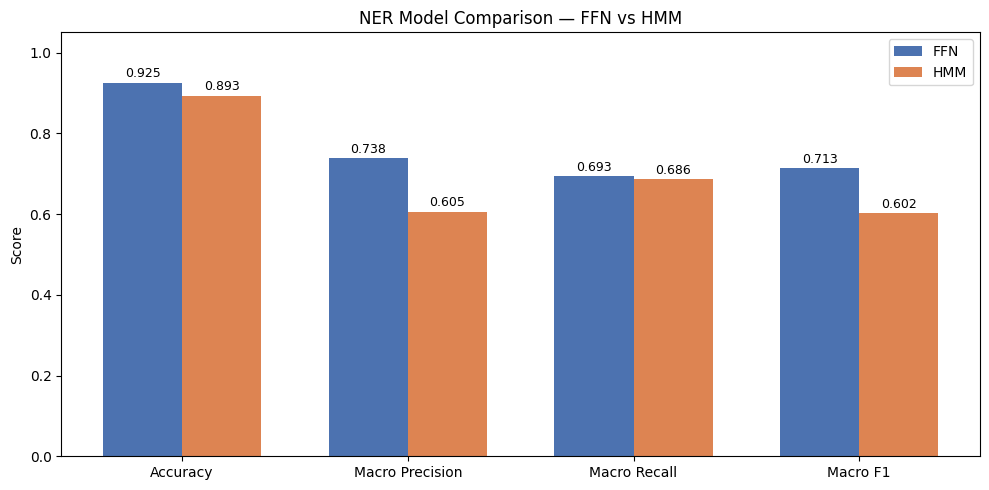

In [27]:
# ── Bar chart comparison ──
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']
ffn_vals = [float(rows[0][m]) for m in metrics]
hmm_vals = [float(rows[1][m]) for m in metrics]

x_pos = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x_pos - width/2, ffn_vals, width, label='FFN', color='#4c72b0')
bars2 = ax.bar(x_pos + width/2, hmm_vals, width, label='HMM', color='#dd8452')

ax.set_ylabel('Score')
ax.set_title('NER Model Comparison — FFN vs HMM')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.legend()

for bar in bars1 + bars2:
    h = bar.get_height()
    ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 4), textcoords='offset points',
                ha='center', fontsize=9)

plt.tight_layout()
plt.show()
